# 1. Project Objective

## Sales Analysis - Olist E-commerce Dataset

This project analyzes sales data from the Brazilian Olist e-commerce dataset.

The goal is to answer:

1. Which product categories generate the most revenue?
2. How does monthly revenue evolve over time?
3. Which categories have more consistent revenue?
4. Are there incomplete periods in the dataset?

# 2. Import Libraries

In [1]:
import pandas as pd # Pandas is used for data manipulation and analysis
import matplotlib.pyplot as plt

# 3. Load Data

In [2]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')

# 4. Merge Data

In [3]:
df = items.merge(orders, on='order_id')
df = df.merge(products, on='product_id')

# 5. Data Cleaning

## 5.1 Check order status

In [4]:
df['order_status'].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

## 5.2 Keep only delivered orders

In [5]:
df = df[df['order_status'] == 'delivered']

## 5.3 Create revenue column

In [6]:
df['revenue'] = df['price']

## 5.4 Check missing values

In [7]:
df.isna().sum().sort_values(ascending=False)

product_description_lenght       1537
product_photos_qty               1537
product_category_name            1537
product_name_lenght              1537
product_height_cm                  18
product_width_cm                   18
product_weight_g                   18
product_length_cm                  18
order_approved_at                  15
order_delivered_customer_date       8
order_delivered_carrier_date        2
product_id                          0
order_item_id                       0
order_id                            0
seller_id                           0
freight_value                       0
price                               0
shipping_limit_date                 0
order_purchase_timestamp            0
order_estimated_delivery_date       0
customer_id                         0
order_status                        0
revenue                             0
dtype: int64

## 5.5 Fill missing product categories

In [8]:
df['product_category_name'] = df['product_category_name'].fillna('unknown')

Missing product categories were filled with "unknown" to preserve valid sales records.

## 5.6 Create month column

In [9]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)


## 5.7 Check orders by month

In [10]:
df.groupby('month')['order_id'].nunique()

month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Name: order_id, dtype: int64

## 5.8 Filter valid analysis period

In [11]:
df = df[(df['month'] >= '2017-01') & (df['month'] <= '2018-08')]

The analysis was restricted to January 2017 through August 2018 to avoid incomplete or low-volume periods.

# 6. Data Overview

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 109880 entries, 0 to 112649
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       109880 non-null  str           
 1   order_item_id                  109880 non-null  int64         
 2   product_id                     109880 non-null  str           
 3   seller_id                      109880 non-null  str           
 4   shipping_limit_date            109880 non-null  str           
 5   price                          109880 non-null  float64       
 6   freight_value                  109880 non-null  float64       
 7   customer_id                    109880 non-null  str           
 8   order_status                   109880 non-null  str           
 9   order_purchase_timestamp       109880 non-null  datetime64[us]
 10  order_approved_at              109865 non-null  str           
 11  order_delivered_

In [13]:
df.describe()

,order_item_id,price,freight_value,order_purchase_timestamp,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,revenue
count,109880.000000,109880.000000,109880.000000,109880,108345.000000,108345.000000,108345.00000,109862.000000,109862.000000,109862.000000,109862.000000,109880.000000
mean,1.197961,119.958383,19.949881,2018-01-03 10:07:22.640526,48.808538,787.243463,2.20995,2089.445395,30.138820,16.549389,22.984972,119.958383
min,1.000000,0.850000,0.000000,2017-01-05 11:56:06,5.000000,4.000000,1.00000,0.000000,7.000000,2.000000,6.000000,0.850000
25%,1.000000,39.900000,13.080000,2017-09-16 19:33:29.250000,42.000000,348.000000,1.00000,300.000000,18.000000,8.000000,15.000000,39.900000
50%,1.000000,74.900000,16.260000,2018-01-21 22:02:57.500000,52.000000,603.000000,1.00000,700.000000,25.000000,13.000000,20.000000,74.900000
75%,1.000000,134.170000,21.150000,2018-05-05 21:39:21.250000,57.000000,986.000000,3.00000,1800.000000,38.000000,20.000000,30.000000,134.170000
max,21.000000,6735.000000,409.680000,2018-08-29 15:00:37,76.000000,3992.000000,20.00000,40425.000000,105.000000,105.000000,118.000000,6735.000000
std,0.706466,182.346158,15.703594,NaN,10.003424,651.277848,1.72102,3741.977242,16.120421,13.409920,11.690344,182.346158


In [14]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,revenue,month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,58.90,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,239.90,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,199.00,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,12.99,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,199.90,2017-02


# 7. Top Categories Analysis

In [15]:
top_categories = (
    df.groupby('product_category_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

product_category_name
beleza_saude              1229557.50
relogios_presentes        1163465.91
cama_mesa_banho           1022955.77
esporte_lazer              952840.40
informatica_acessorios     888055.59
moveis_decoracao           706237.17
utilidades_domesticas      614341.62
cool_stuff                 609158.00
automotivo                 577838.39
ferramentas_jardim         469135.40
Name: revenue, dtype: float64

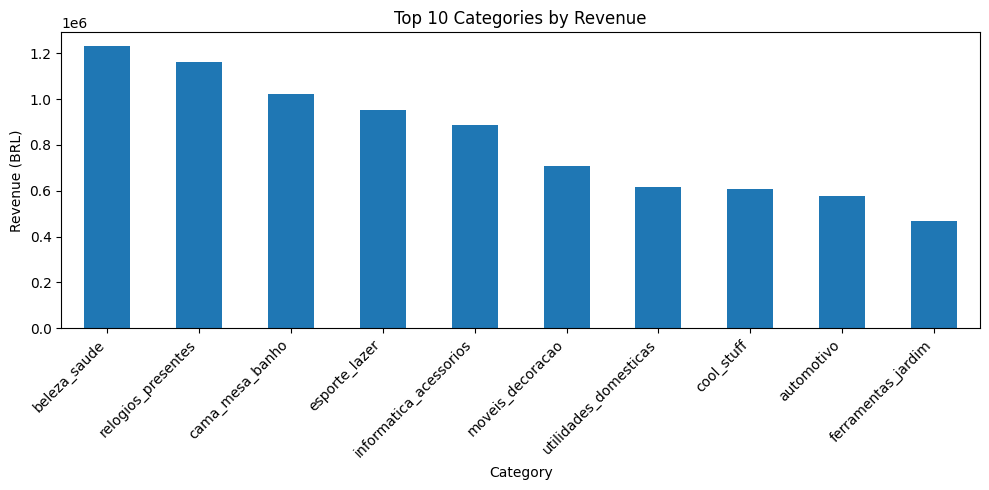

In [16]:
top_categories.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The top revenue categories were health & beauty, watches & gifts, and bed/bath/table. These categories represent the strongest sales drivers in the analyzed period.

# 8. Monthly Revenue Analysis

In [17]:
monthly_revenue = (
    df.groupby('month')['revenue']
    .sum()
)

monthly_revenue

month
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Name: revenue, dtype: float64

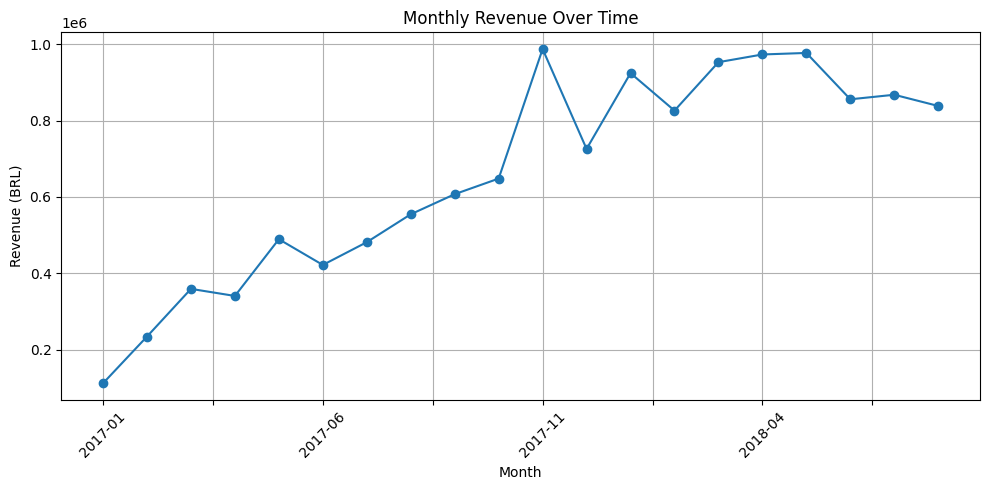

In [18]:
ax = monthly_revenue.plot(kind='line', figsize=(10, 5), marker='o')

plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

Revenue increased throughout 2017, with a strong peak in November, likely influenced by Black Friday. In 2018, revenue remained high and more stable between January and August.

# 9. Category Consistency Analysis

In [19]:
monthly_category_revenue = (
    df.groupby(['product_category_name', 'month'])['revenue']
    .sum()
    .reset_index()
)

monthly_category_revenue.head()

,product_category_name,month,revenue
0,agro_industria_e_comercio,2017-01,65.97
1,agro_industria_e_comercio,2017-02,224.84
2,agro_industria_e_comercio,2017-03,81.99
3,agro_industria_e_comercio,2017-05,1579.94
4,agro_industria_e_comercio,2017-06,1390.00


In [20]:
category_consistency = (
    monthly_category_revenue
    .groupby('product_category_name')['revenue']
    .agg(['median', 'std'])
)

category_consistency['relative_variation'] = (
    category_consistency['std'] / category_consistency['median']
)

category_consistency = category_consistency.sort_values(
    by=['median', 'relative_variation'],
    ascending=[False, True]
)

category_consistency.head(10)

,median,std,relative_variation
product_category_name,,,
relogios_presentes,62799.970,32305.938148,0.514426
beleza_saude,55668.955,32396.882368,0.581956
cama_mesa_banho,55492.930,22201.240422,0.400073
esporte_lazer,48770.545,21071.031204,0.432044
informatica_acessorios,40557.975,24207.913611,0.596872
cool_stuff,33753.505,11997.843037,0.355455
moveis_decoracao,32334.490,14801.154269,0.457751
automotivo,32036.100,14173.072722,0.442409
utilidades_domesticas,24356.900,18101.891719,0.743194


This analysis indentifies categories with strong and stable monthly revenue, using median revenue and relative variation.

# 10. Final Insights
- The highest revenue categories were beauty & health, watches & gifts, and bed/bath/table.
- Revenue increased throughout 2017 and reached its highest point in November.
- The analysis period was restricted to January 2017 through August 2018 to avoid incomplete months
- Some categories showed both high revenue and stable monthly performance, making them more relevant for business planning.